# Library

In [6]:
# 기본 라이브러리
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 머신러닝 관련 라이브러리
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

# Load the dataset

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lavanyashukla01/particle-identification")

print("Path to dataset files:", path)

Path to dataset files: /home/student/2021/s2021550006/.cache/kagglehub/datasets/lavanyashukla01/particle-identification/versions/1


In [10]:
import pandas as pd
import os

# 데이터 저장 경로 (사용자 환경에 따라 다를 수 있음)
base_path = "/Users/Jongseok/.cache/kagglehub/datasets/lavanyashukla01/particle-identification/versions/1"

print(f"데이터 폴더 확인: {base_path}")

# 1. 폴더 안에 있는 파일 목록 확인
if os.path.exists(base_path):
    file_list = os.listdir(base_path)
    print("파일 목록:", file_list)
    
    # 2. CSV 파일 찾기 (보통 training.csv 또는 data.csv)
    csv_files = [f for f in file_list if f.endswith('.csv')]
    
    if len(csv_files) > 0:
        full_path1 = os.path.join(base_path, csv_files[0])
        full_path2 = os.path.join(base_path, csv_files[1])

        train_df = pd.read_csv(full_path1)
        test_df = pd.read_csv(full_path2)
        
        print(f"Load complete: {train_df.shape}")
        print(f"Load complete: {test_df.shape}")
            
    else:
        print("❌ 폴더는 찾았지만, .csv 파일이 보이지 않습니다. 압축(.zip)이 덜 풀렸는지 확인이 필요합니다.")
else:
    print(f"❌ 경로를 찾을 수 없습니다: {base_path}")

데이터 폴더 확인: /Users/Jongseok/.cache/kagglehub/datasets/lavanyashukla01/particle-identification/versions/1
파일 목록: ['training.csv', 'test.csv']
Load complete: (1200000, 50)
Load complete: (1200000, 50)


# Data Preprocessing

## Data Inspection

In [29]:
df = train_df.copy()
# 데이터프레임 정보 확인 (간략하게)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200000 entries, 0 to 1199999
Data columns (total 50 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   TrackP                           1200000 non-null  float64
 1   TrackNDoFSubdetector2            1200000 non-null  float64
 2   BremDLLbeElectron                1200000 non-null  float64
 3   MuonLooseFlag                    1200000 non-null  float64
 4   FlagSpd                          1200000 non-null  float64
 5   SpdE                             1200000 non-null  float64
 6   EcalDLLbeElectron                1200000 non-null  float64
 7   DLLmuon                          1200000 non-null  float64
 8   RICHpFlagElectron                1200000 non-null  float64
 9   EcalDLLbeMuon                    1200000 non-null  float64
 10  TrackQualitySubdetector2         1200000 non-null  float64
 11  FlagPrs                          1200000 non-null 

In [30]:
df.head()

,TrackP,TrackNDoFSubdetector2,BremDLLbeElectron,MuonLooseFlag,FlagSpd,SpdE,EcalDLLbeElectron,DLLmuon,RICHpFlagElectron,EcalDLLbeMuon,...,TrackNDoF,RICHpFlagMuon,RICH_DLLbeKaon,RICH_DLLbeElectron,HcalE,MuonFlag,FlagMuon,PrsE,RICH_DLLbeMuon,RICH_DLLbeProton
0,74791.156263,15.0,0.232275,1.0,1.0,3.2,-2.505719,6.604153,1.0,1.929960,...,28.0,1.0,-7.213300,-0.280200,5586.589846,1.0,1.0,10.422315,-2.081143e-07,-24.824400
1,2738.489989,15.0,-0.357748,0.0,1.0,3.2,1.864351,0.263651,1.0,-2.061959,...,32.0,1.0,-0.324317,1.707283,-0.000007,0.0,1.0,43.334935,2.771583e+00,-0.648017
2,2161.409908,17.0,-999.000000,0.0,0.0,-999.0,-999.000000,-999.000000,0.0,-999.000000,...,27.0,0.0,-999.000000,-999.000000,-999.000000,0.0,0.0,-999.000000,-9.990000e+02,-999.000000
3,15277.730490,20.0,-0.638984,0.0,1.0,3.2,-2.533918,-8.724949,1.0,-3.253981,...,36.0,1.0,-35.202221,-14.742319,4482.803707,0.0,1.0,2.194175,-3.070819e+00,-29.291519
4,7563.700195,19.0,-0.638962,0.0,1.0,3.2,-2.087146,-7.060422,1.0,-0.995816,...,33.0,1.0,25.084287,-10.272412,5107.554680,0.0,1.0,0.000015,-5.373712e+00,23.653087


- Head()를 통해 데이터 확인 후, -999와 같은 이상치 확인 

    - 이는 보통 NaN값 대신 채워지는 값으로, 이상치 처리 필요
    - 이를 그대로 두가 정규화 할 경우, 분포가 심각하게 망가짐

In [31]:
df.columns

Index(['TrackP', 'TrackNDoFSubdetector2', 'BremDLLbeElectron', 'MuonLooseFlag',
       'FlagSpd', 'SpdE', 'EcalDLLbeElectron', 'DLLmuon', 'RICHpFlagElectron',
       'EcalDLLbeMuon', 'TrackQualitySubdetector2', 'FlagPrs', 'DLLelectron',
       'DLLkaon', 'EcalE', 'TrackQualityPerNDoF', 'DLLproton',
       'PrsDLLbeElectron', 'FlagRICH1', 'MuonLLbeBCK', 'FlagHcal',
       'EcalShowerLongitudinalParameter', 'Calo2dFitQuality', 'TrackPt',
       'TrackDistanceToZ', 'RICHpFlagPion', 'HcalDLLbeElectron',
       'Calo3dFitQuality', 'FlagEcal', 'MuonLLbeMuon', 'TrackNDoFSubdetector1',
       'RICHpFlagProton', 'RICHpFlagKaon', 'GhostProbability',
       'TrackQualitySubdetector1', 'Label', 'RICH_DLLbeBCK', 'FlagRICH2',
       'FlagBrem', 'HcalDLLbeMuon', 'TrackNDoF', 'RICHpFlagMuon',
       'RICH_DLLbeKaon', 'RICH_DLLbeElectron', 'HcalE', 'MuonFlag', 'FlagMuon',
       'PrsE', 'RICH_DLLbeMuon', 'RICH_DLLbeProton'],
      dtype='object')

In [32]:
# 중복 행 개수 확인
df.duplicated().sum()

np.int64(0)

In [33]:
df['Label'].unique()

array(['Muon', 'Ghost', 'Pion', 'Proton', 'Kaon', 'Electron'],
      dtype=object)

In [35]:
# 결측치 확인
print(df.isnull().sum())

TrackP                             0
TrackNDoFSubdetector2              0
BremDLLbeElectron                  0
MuonLooseFlag                      0
FlagSpd                            0
SpdE                               0
EcalDLLbeElectron                  0
DLLmuon                            0
RICHpFlagElectron                  0
EcalDLLbeMuon                      0
TrackQualitySubdetector2           0
FlagPrs                            0
DLLelectron                        0
DLLkaon                            0
EcalE                              0
TrackQualityPerNDoF                0
DLLproton                          0
PrsDLLbeElectron                   0
FlagRICH1                          0
MuonLLbeBCK                        0
FlagHcal                           0
EcalShowerLongitudinalParameter    0
Calo2dFitQuality                   0
TrackPt                            0
TrackDistanceToZ                   0
RICHpFlagPion                      0
HcalDLLbeElectron                  0
C

## Data Preprocessing

## Feature Engineering

## 윤하의 XGBoost modeling code

  Train shape: (1200000, 50)
  Test shape : (1200000, 50)

Step 3: Aligning Columns...
   Selected 58 features for the model.


/opt/anaconda3/envs/SDS_env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/SDS_env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/SDS_env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/SDS_env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/SDS_env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/SDS_env/lib/python3.11/si

   Column alignment successful.

Step 4: Scaling Data...

Step 5: Training XGBoost Model...
   Training Completed!

Step 6: Predicting on Test Data...

[Prediction Sample]
   ID     Label
0   0    Proton
1   1    Proton
2   2    Proton
3   3  Electron
4   4    Proton

✅ Success! 'submission.csv' has been saved.

[Feature Importance Top 10]


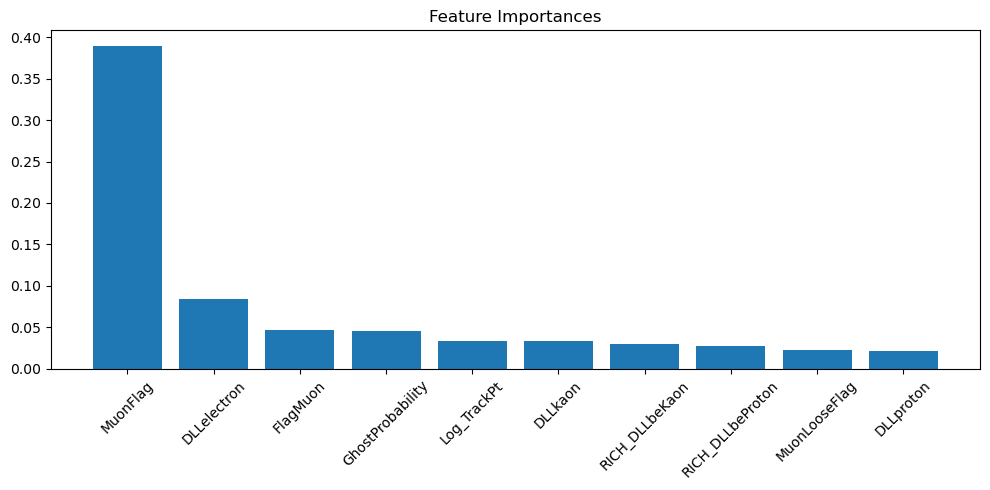

In [ ]:
# Define Feature Engineering Function
def make_features(df):
    
    # Physics Ratios (Add 1e-6 to avoid division by zero)
    # E/P ratio is critical for electron identification
    df['E_over_P'] = df['EcalE'] / (df['TrackP'] + 1e-6)
    df['H_over_P'] = df['HcalE'] / (df['TrackP'] + 1e-6)
    df['Pt_Ratio'] = df['TrackPt'] / (df['TrackP'] + 1e-6)
    
    # Log Transformation for heavy-tailed variables
    cols_to_log = ['TrackP', 'TrackPt', 'EcalE', 'HcalE', 'PrsE', 'SpdE']
    
    for col in cols_to_log:
        if col in df.columns:
            df[f'Log_{col}'] = np.log1p(df[col])
            
    return df

print(f"  Train shape: {train_df.shape}")
print(f"  Test shape : {test_df.shape}")

# Apply Feature Engineering
train_df = make_features(train_df)
test_df = make_features(test_df)

# Column Alignment & Preparation
print("\nStep 3: Aligning Columns...")

# List of columns to exclude from input features
ignore_cols = ['Label', 'ID']

# Select only feature columns present in Train
feature_cols = [c for c in train_df.columns if c not in ignore_cols]

print(f"   Selected {len(feature_cols)} features for the model.")

# Create Input Matrices
X_train = train_df[feature_cols]
X_test = test_df[feature_cols]

# Check if columns match perfectly
assert list(X_train.columns) == list(X_test.columns), "Error: Column mismatch!"
print("   Column alignment successful.")

# Prepare Target Vector
label_mapping = {
    'Electron': 0, 
    'Ghost': 1, 
    'Kaon': 2, 
    'Muon': 3, 
    'Pion': 4, 
    'Proton': 5
}
y_train = train_df['Label'].map(label_mapping)

# Save Test IDs for submission file
if 'ID' in test_df.columns:
    test_ids = test_df['ID']
else:
    test_ids = test_df.index

# Scaling
print("\nStep 4: Scaling Data...")
scaler = StandardScaler()

# Fit on Train, Transform on Train
X_train_scaled = scaler.fit_transform(X_train)

# Transform on Test
X_test_scaled = scaler.transform(X_test)

# Model Training (XGBoost)
print("\nStep 5: Training XGBoost Model...")
model = XGBClassifier(
    n_estimators=200,     # Number of trees
    learning_rate=0.1,    # Step size shrinkage
    max_depth=10,         # Maximum depth of a tree
    random_state=42,      # Seed for reproducibility
    n_jobs=-1             # Use all CPU cores
)

model.fit(X_train_scaled, y_train)
print("   Training Completed!")

# Prediction & Submission
print("\nStep 6: Predicting on Test Data...")
y_pred_code = model.predict(X_test_scaled)

# Convert integer codes back to string labels
reverse_mapping = {v: k for k, v in label_mapping.items()}
y_pred_name = [reverse_mapping[code] for code in y_pred_code]

# Create DataFrame for submission
submission = pd.DataFrame({
    'ID': test_ids,
    'Label': y_pred_name
})

# Show sample
print("\n[Prediction Sample]")
print(submission.head())

# Save to CSV
submission.to_csv('submission.csv', index=False)
print("\n✅ Success! 'submission.csv' has been saved.")

# Feature Importance Visualization
print("\n[Feature Importance Top 10]")
importances = model.feature_importances_
indices = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(10, 5))
plt.title("Feature Importances")
plt.bar(range(10), importances[indices], align="center")
plt.xticks(range(10), [feature_cols[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()

In [7]:
result_df = pd.read_csv('submission.csv')

print("Total predictions:", len(result_df))
print("\n[First 10 Predictions]")
display(result_df.head(10))

Total predictions: 1200000

[First 10 Predictions]


,ID,Label
0,0,Proton
1,1,Proton
2,2,Proton
3,3,Electron
4,4,Proton
5,5,Pion
6,6,Muon
7,7,Proton
8,8,Muon
9,9,Proton



[Comparison of Particle Ratios]


,Training (Actual),Test (Predicted)
Label,,
Electron,0.166667,0.168079
Ghost,0.166667,0.173574
Kaon,0.166667,0.159956
Muon,0.166667,0.166719
Pion,0.166667,0.179862
Proton,0.166667,0.151810


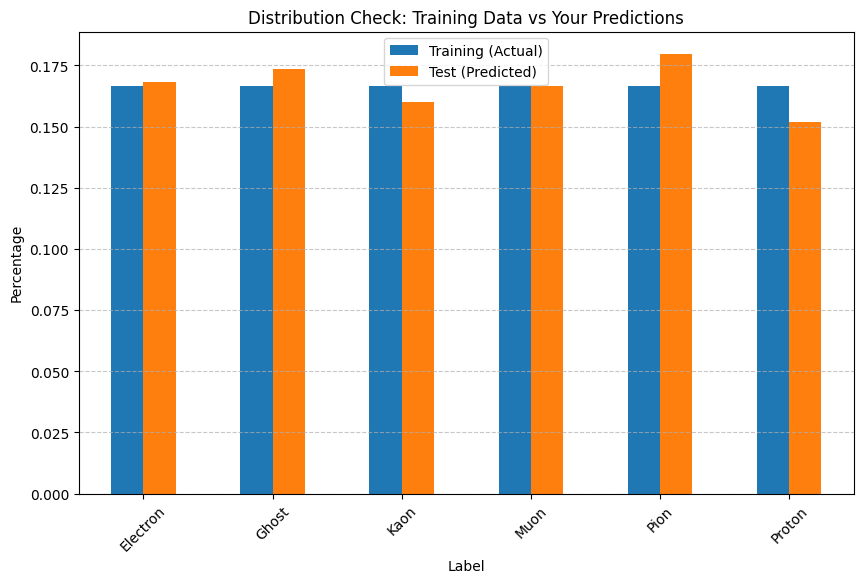

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate counts
train_counts = train_df['Label'].value_counts(normalize=True) # Actual
pred_counts = result_df['Label'].value_counts(normalize=True) # Predicted

# Comparison DataFrame
comparison = pd.DataFrame({
    'Training (Actual)': train_counts,
    'Test (Predicted)': pred_counts
}).fillna(0)

print("\n[Comparison of Particle Ratios]")
display(comparison)

comparison.plot(kind='bar', figsize=(10, 6))
plt.title("Distribution Check: Training Data vs Your Predictions")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Use only training data for this test
X_part_train, X_val, y_part_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Train on 80%
print("Training on 80% of data to estimate accuracy...")
model_val = XGBClassifier(
    n_estimators=100, 
    max_depth=10, 
    n_jobs=-1, 
    random_state=42
)
model_val.fit(X_part_train, y_part_train)

# Test on 20%
y_val_pred = model_val.predict(X_val)

acc = accuracy_score(y_val, y_val_pred)
print(f"\n✅ Estimated Model Accuracy: {acc:.4f} ({acc*100:.2f}%)")

Training on 80% of data to estimate accuracy...

✅ Estimated Model Accuracy: 0.7796 (77.96%)
